In [3]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ds = pd.read_csv('nhldraft.csv')
ds.head(5)
print(f"Число строк {ds.shape[0]}, столбцов {ds.shape[1]}")

ds.info() #тип, имя колонок, а также количетсво ненулевых значений 



Число строк 12250, столбцов 23
<class 'pandas.DataFrame'>
RangeIndex: 12250 entries, 0 to 12249
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     12250 non-null  int64  
 1   year                   12250 non-null  int64  
 2   overall_pick           12250 non-null  int64  
 3   team                   12249 non-null  str    
 4   player                 12250 non-null  str    
 5   nationality            12246 non-null  str    
 6   position               12223 non-null  str    
 7   age                    8291 non-null   float64
 8   to_year                5246 non-null   float64
 9   amateur_team           12250 non-null  str    
 10  games_played           5246 non-null   float64
 11  goals                  5246 non-null   float64
 12  assists                5246 non-null   float64
 13  points                 5246 non-null   float64
 14  plus_minus             5234 non-nu

In [5]:
ds.describe() #расписывает каждый параметр типа int, float
#ds.describe(include='object') для строчных парметров 
ds.isnull().sum() #выводит число пустых значений для парметров 
#ds.dropna() удалит все строки где есть хотя бы один Nan, None
df = ds[ds['year'] >= 2019 ] #делать выборку по всем игрокам слишком тупо, поэтому возьмем свежих игроков с драфта не позднее 2019

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     881 non-null    int64  
 1   year                   881 non-null    int64  
 2   overall_pick           881 non-null    int64  
 3   team                   881 non-null    str    
 4   player                 881 non-null    str    
 5   nationality            881 non-null    str    
 6   position               881 non-null    str    
 7   age                    881 non-null    float64
 8   to_year                88 non-null     float64
 9   amateur_team           881 non-null    str    
 10  games_played           88 non-null     float64
 11  goals                  88 non-null     float64
 12  assists                88 non-null     float64
 13  points                 88 non-null     float64
 14  plus_minus             86 non-null     float64
 15  penalties_minutes

In [6]:
cols_to_fill = ['games_played', 'goals', 'assists', 'points', 'plus_minus', 'penalties_minutes']
#df[cols_to_fill] = df[cols_to_fill].fillna(0) #заменяем поля с отсутсвующими данными на нули. Почему? Если игрок не сыграл в НХЛ, его статистика будет равна нулю в соответсвующих столбцах
# я закоментировал , т.к в последствии оказалось, что подсчета новых парметров, лучше оставить значения у игроков не игравших в нхл nan
mod = df['to_year'].mode()
df['to_year'] = df['to_year'].fillna(mod)[0] #почему мода? Значение to_year стояло у игроков уже дебютировавших в НХЛ. И очевидно, что игрок может продолжать карьеру даже не играя в НХЛ. Хотя можно было и просто 2022 написать, т.к маловероятно что кто-то бы завершил карьеру, 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     881 non-null    int64  
 1   year                   881 non-null    int64  
 2   overall_pick           881 non-null    int64  
 3   team                   881 non-null    str    
 4   player                 881 non-null    str    
 5   nationality            881 non-null    str    
 6   position               881 non-null    str    
 7   age                    881 non-null    float64
 8   to_year                881 non-null    float64
 9   amateur_team           881 non-null    str    
 10  games_played           88 non-null     float64
 11  goals                  88 non-null     float64
 12  assists                88 non-null     float64
 13  points                 88 non-null     float64
 14  plus_minus             86 non-null     float64
 15  penalties_minutes

In [7]:
max_gp = df['games_played'].max()
max_g = df['goals'].max()
max_a = df['assists'].max()
max_p = df['points'].max()
#min нет смысла вычислять, это значение будет равно 0

points_avg = df['points'].mean()
games_med = df['games_played'].median()
print(max_gp, max_g, max_a, max_p, sep="; ", end="\n")
print(points_avg, games_med, sep=" ")

top5_points = df.nlargest(5, 'points')[['player', 'year', 'team', 'points', 'goals', 'assists']]
print("Топ-5 игроков по очкам:")
print(top5_points) #узнал о методе nlargest который помогает вывести определенную выборку с определнными столбцами. Антоним ему - nsmallest

top_2021 = df[df['year'] == 2021][df['games_played'].notna()][['player', 'team', 'games_played']] #выборка с условием. Данная выборка позволила посмотреть какие игроки с драфта 2021 смогли дебютировать в свой первый сезон
print(top_2021)

p90 = df['points'].quantile(0.9) #90 процентов игроков с драфта с 2019 и позже имеют менее 48.6 очков за карьеру 
print(p90)


166.0; 44.0; 64.0; 108.0
15.090909090909092 16.5
Топ-5 игроков по очкам:
            player  year                team  points  goals  assists
664    Jack Hughes  2019   New Jersey Devils   108.0   44.0     64.0
450    Tim Stützle  2020     Ottawa Senators    87.0   34.0     53.0
672  Trevor Zegras  2019       Anaheim Ducks    74.0   26.0     48.0
666     Kirby Dach  2019  Chicago Blackhawks    59.0   19.0     40.0
665    Kaapo Kakko  2019    New York Rangers    58.0   26.0     32.0
              player                   team  games_played
225       Owen Power         Buffalo Sabres           8.0
226  Matthew Beniers         Seattle Kraken          10.0
227   Mason Mctavish          Anaheim Ducks           9.0
229     Kent Johnson  Columbus Blue Jackets           9.0
231   William Eklund        San Jose Sharks           9.0
235   Cole Sillinger  Columbus Blue Jackets          79.0
283      Janis Moser        Arizona Coyotes          43.0
48.599999999999994


C:\Users\sdfg5\AppData\Local\Temp\ipykernel_9132\3090275150.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  top_2021 = df[df['year'] == 2021][df['games_played'].notna()][['player', 'team', 'games_played']] #выборка с условием. Данная выборка позволила посмотреть какие игроки с драфта 2021 смогли дебютировать в свой первый сезон


In [8]:
#ДЛЯ ДАЛЬНЕЙШИХ ДЕЙСТВИЙ ВЕРНЕМСЯ КО ВСЕМУ ДАТАСЕТУ ds и создадим на его базе новый, в котором будут игроки у которых ест сыгранные матчи 
stats = ds[ds['games_played'].notna()]


# как мы видим, после этого отбора почти все данные есть, заполним пропуски средними значениями / уберем незаполненные строки у вратарей
plmi = stats['plus_minus'].mean()
stats['plus_minus'] = stats['plus_minus'].fillna(plmi)
#stats.info()

goalie = stats[(stats['position']=='G') & (stats['goalie_wins'].isna())].index
stats.drop(index = goalie, inplace = True)
stats.info()


<class 'pandas.DataFrame'>
Index: 5244 entries, 225 to 12249
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     5244 non-null   int64  
 1   year                   5244 non-null   int64  
 2   overall_pick           5244 non-null   int64  
 3   team                   5244 non-null   str    
 4   player                 5244 non-null   str    
 5   nationality            5244 non-null   str    
 6   position               5244 non-null   str    
 7   age                    5244 non-null   float64
 8   to_year                5244 non-null   float64
 9   amateur_team           5244 non-null   str    
 10  games_played           5244 non-null   float64
 11  goals                  5244 non-null   float64
 12  assists                5244 non-null   float64
 13  points                 5244 non-null   float64
 14  plus_minus             5244 non-null   float64
 15  penalties_minutes

In [9]:
#дисперсия
variance = stats['points'].var()
print(variance)
sr = stats['points'].mean()
print(sr)
print(np.sqrt(variance))

54219.62902827249
135.94832189168574
232.85108766821872


In [10]:
print(stats['points'].skew()) 
#ассиметрия 

2.793880650513774


In [11]:
print(stats['points'].kurtosis())
#эксцесс

9.783342622861042


Дисперсия в нашем датасете и конкретно в параметре очков дает нам возомжность посмотреть на разницу данных относительно среднего. В нашем случае разница гигантская и довольно легко понять почему. Довольно большое число задрафтованных игроков сыграют совсем небольшое количество матчей и наберут там малое количество очков. В то же время есть и суперзвезды, которые наберут 1000+ , 1500+ очков что очень сильно разнится с большинством. В принципе подтверждается утверждение , что игроков много, а звезд - единицы.

Ассиметрия показывает сотношение людей около среднего значения. В нашем случае значение получилось положительное, что означает перекос в количестве игроков набравших мало очков (их намного больше) и тех кто набрал больше среднего числа

Эксцесс показывает сколько выбросов у нас есть. У нас , понятное дело, много игроков с околонулевым или небольшим показателем очков и в тоже время есть суперзвезды набравшие 2500+ очков (Уэйн Гретцки), 1500+ что очень сильно разнится со среднем значение и основной массой и создает выбросы



In [12]:
stats['position'].value_counts()
#

position
D        1603
C        1189
LW        920
RW        908
G         488
C/LW       39
C/RW       31
W          19
LW/C       16
RW/C        6
LW/D        5
D/LW        4
C/D         3
D/RW        3
C; LW       2
C/W         2
RW/D        2
C RW        1
L/RW        1
F           1
D/W         1
Name: count, dtype: int64

In [13]:
ohc = pd.get_dummies(stats['position'])
stats_encoded = pd.concat([stats, ohc], axis=1)
check_cols = ['player', 'position'] + list(ohc.columns[:21])
print(stats_encoded[check_cols])


                player position      C   C RW    C/D   C/LW   C/RW    C/W  \
225         Owen Power        D  False  False  False  False  False  False   
226    Matthew Beniers        C   True  False  False  False  False  False   
227     Mason Mctavish        C   True  False  False  False  False  False   
229       Kent Johnson        C   True  False  False  False  False  False   
231     William Eklund       LW  False  False  False  False  False  False   
...                ...      ...    ...    ...    ...    ...    ...    ...   
12229    Garry Monahan       LW  False  False  False  False  False  False   
12230   Pete Mahovlich        C   True  False  False  False  False  False   
12234   Walt McKechnie        C   True  False  False  False  False  False   
12245      Jim McKenny        D  False  False  False  False  False  False   
12249     Gerry Meehan        C   True  False  False  False  False  False   

       C; LW      D  ...      F      G   L/RW     LW   LW/C   LW/D     RW  

In [14]:
stats.head(2)
stats['nationality'].unique()

<StringArray>
['CA', 'US', 'CH', 'SE', 'DE', 'AT', 'FI', 'RU', 'CZ', 'UZ', 'DK', 'BY', 'AU',
 'SK', 'FR', 'BE', 'NL', 'UA', 'LV', 'GB', 'LT', 'IT', 'NO', 'NG', 'EE', 'SI',
 'JP', 'PL', 'KZ', 'BS', 'YU', 'BR', 'TZ', 'BN', 'KR', 'ZA', 'SU', 'HT', 'TW',
 'PY', 'VE']
Length: 41, dtype: str

In [15]:
# создание новых признаков 
stats['points_per_game'] = stats['points'] / stats['games_played']
stats['career_length'] = stats['to_year'] - stats['year']
stats.head(30)

,id,year,overall_pick,team,player,nationality,position,age,to_year,amateur_team,...,penalties_minutes,goalie_games_played,goalie_wins,goalie_losses,goalie_ties_overtime,save_percentage,goals_against_average,point_shares,points_per_game,career_length
225,226,2021,1,Buffalo Sabres,Owen Power,CA,D,18.0,2022.0,Michigan (Big Ten),...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0.9,0.375000,1.0
226,227,2021,2,Seattle Kraken,Matthew Beniers,US,C,18.0,2022.0,Michigan (Big Ten),...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.9,0.900000,1.0
227,228,2021,3,Anaheim Ducks,Mason Mctavish,CH,C,18.0,2022.0,Peterborough Petes (OHL),...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0.4,0.333333,1.0
229,230,2021,5,Columbus Blue Jackets,Kent Johnson,CA,C,18.0,2022.0,Michigan (Big Ten),...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.333333,1.0
231,232,2021,7,San Jose Sharks,William Eklund,SE,LW,18.0,2022.0,Djurgardens IF (Sweden),...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0.1,0.444444,1.0
235,236,2021,12,Columbus Blue Jackets,Cole Sillinger,US,C,18.0,2022.0,Sioux Falls Stampede (USHL),...,37.0,NaN,NaN,NaN,NaN,NaN,NaN,1.9,0.392405,1.0
283,284,2021,60,Arizona Coyotes,Janis Moser,CH,D,21.0,2022.0,EHC Biel-Bienne (Swiss),...,16.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.348837,1.0
448,449,2020,1,New York Rangers,Alexis Lafreniere,CA,LW,18.0,2022.0,Rimouski Oceanic (QMJHL),...,45.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.385185,2.0
449,450,2020,2,Los Angeles Kings,Quinton Byfield,CA,C,18.0,2022.0,Sudbury Wolves (OHL),...,22.0,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.239130,2.0
450,451,2020,3,Ottawa Senators,Tim Stützle,DE,LW,18.0,2022.0,Adler Mannheim (Germany),...,51.0,NaN,NaN,NaN,NaN,NaN,NaN,7.0,0.659091,2.0


C:\Users\sdfg5\AppData\Local\Temp\ipykernel_9132\3181529726.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\sdfg5\AppData\Local\Temp\ipykernel_9132\3181529726.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


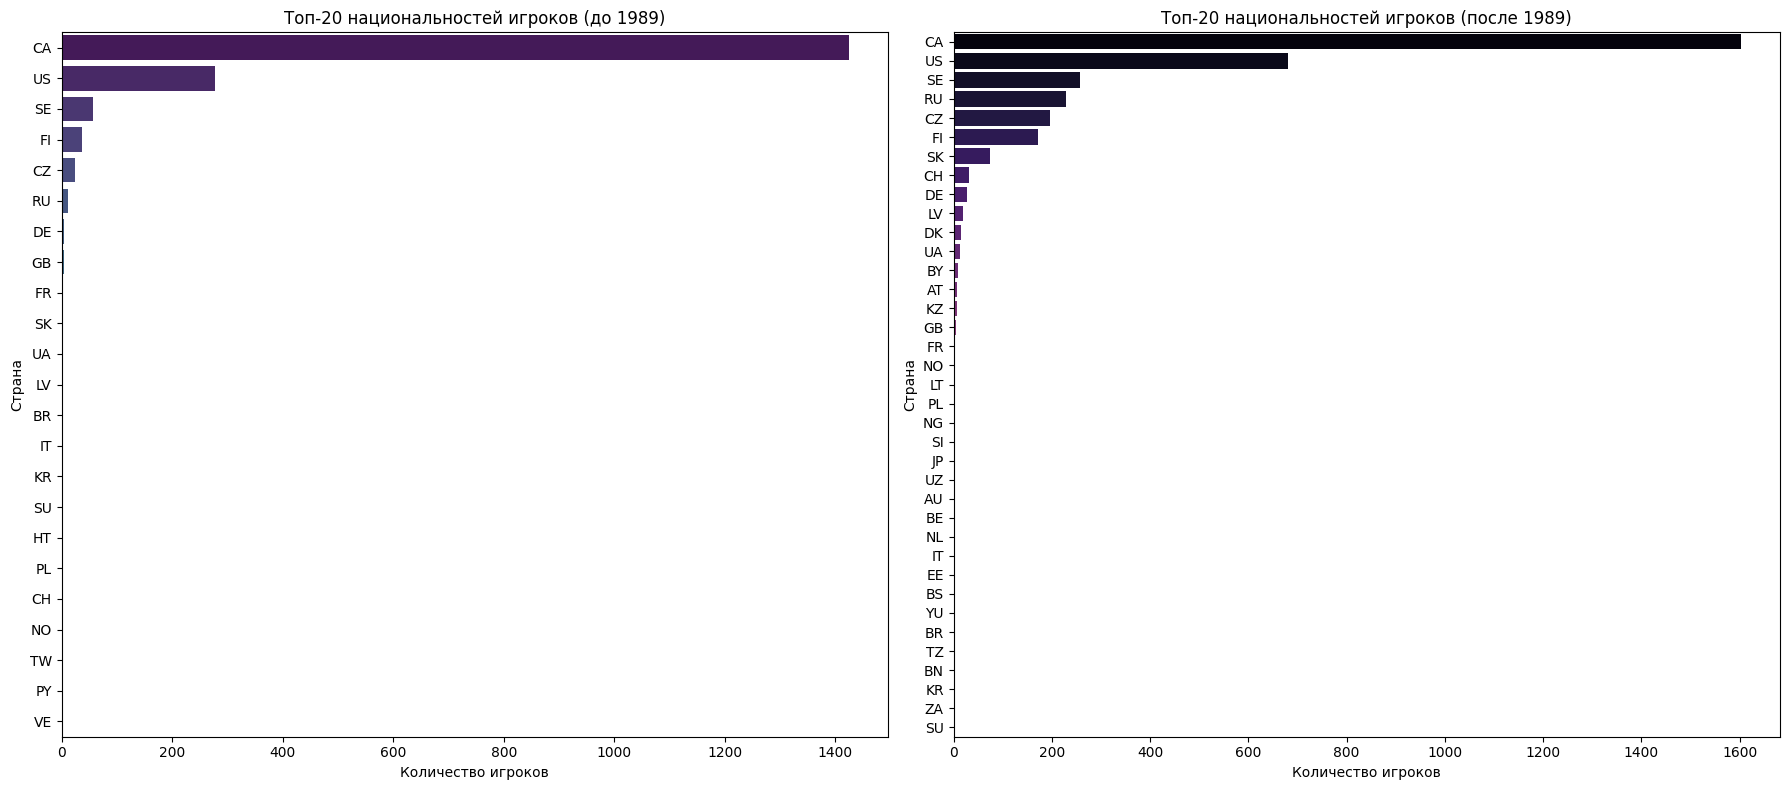

In [16]:
import seaborn as sns
import plotly as pl

top20 = (
    df['nationality']
    .value_counts()
    .head(20)
    .index
)

before_1989 = stats[stats['year'] < 1989]
after_1989 = stats[stats['year'] >= 1989]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

#использован каунтплот так как здесь распределение по странам , то есть категориальное распределение
sns.countplot(
    data=before_1989,
    y='nationality',
    order=before_1989['nationality'].value_counts().index,
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title("Топ‑20 национальностей игроков (до 1989)")
axes[0].set_xlabel("Количество игроков")
axes[0].set_ylabel("Страна")

sns.countplot(
    data=after_1989,
    y='nationality',
    order=after_1989['nationality'].value_counts().index,
    ax=axes[1],
    palette='magma'
)
axes[1].set_title("Топ‑20 национальностей игроков (после 1989)")
axes[1].set_xlabel("Количество игроков")
axes[1].set_ylabel("Страна")

plt.tight_layout()
plt.show()

In [17]:
import plotly.express as px

plot_data = stats[stats['games_played'] > 100].copy()  # минимум 100 матчей 

fig = px.scatter(plot_data, x='year', y='points_per_game', 
                 color='position', 
                 size='points', 
                 hover_data=['player', 'year', 'team', 'goals', 'assists'],
                 title='Эффективность игроков НХЛ (PPG) в зависимости от года их драфта',
                 labels={'games_played': 'Сыгранные матчи', 
                         'points_per_game': 'Очков за игру',
                         'year': 'год драфта'})

fig.add_vline(x = 1994, line_width = 1, line_dash = 'solid', line_color = "black", annotation_text = "1994", annotation_position = "top")
fig.add_vline(x = 2004, line_width = 1, line_dash = 'solid', line_color = "black", annotation_text = "2004", annotation_position = "top")
fig.add_vrect(x0=1994, x1=2004, fillcolor="gray", opacity=0.5, line_width=1,
              annotation_text="Мертвая шайба", annotation_position="top")
fig.update_layout(width=1000, height=600)
fig.show()

**Эпоха мертвой шайбы - период в истории НХЛ, который характеризуется высоким порогом дозволенного в правилах, низкой результативностью и оборонительным стилем игры. 
Из графика видно, что в данное десятилетие игроки попавшие в нхл , а также пришедшие за пару лет до этого, за редчайшим исключением, пробивали отметку в одно очко в среднем за игру. Особенно это выделяется на фоне эпохи 70-x, 80-x годов, на которые пришелся пик результативности. После локаутного сезона 2004/05 где были изменены многие правила, средняя результативность выросла

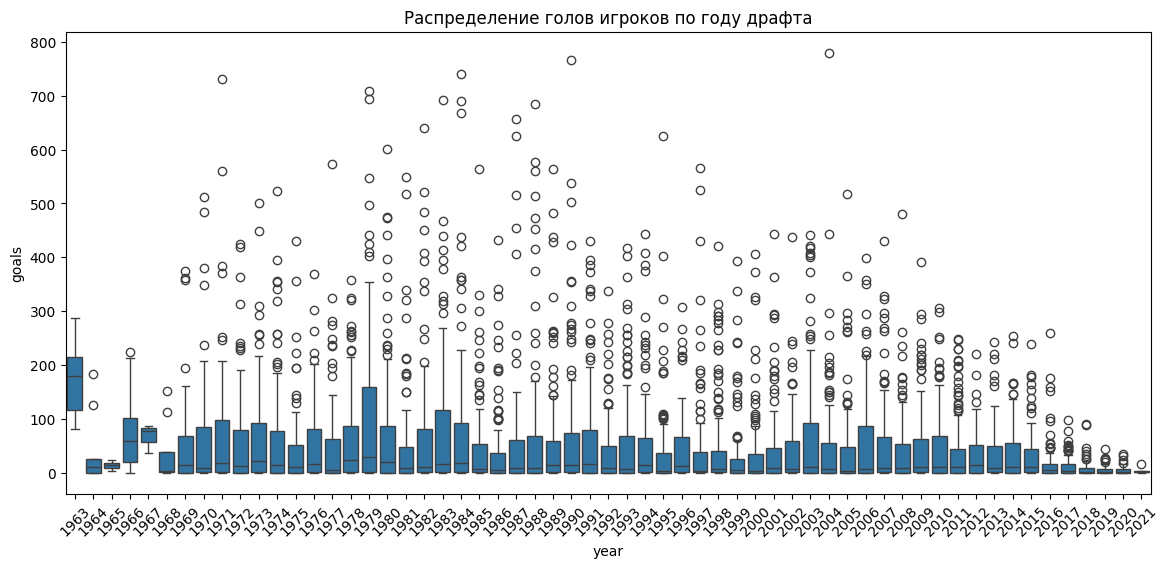

In [25]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=stats, x='year', y='goals')
plt.title('Распределение голов игроков по году драфта')
plt.xticks(rotation=45)
plt.show()

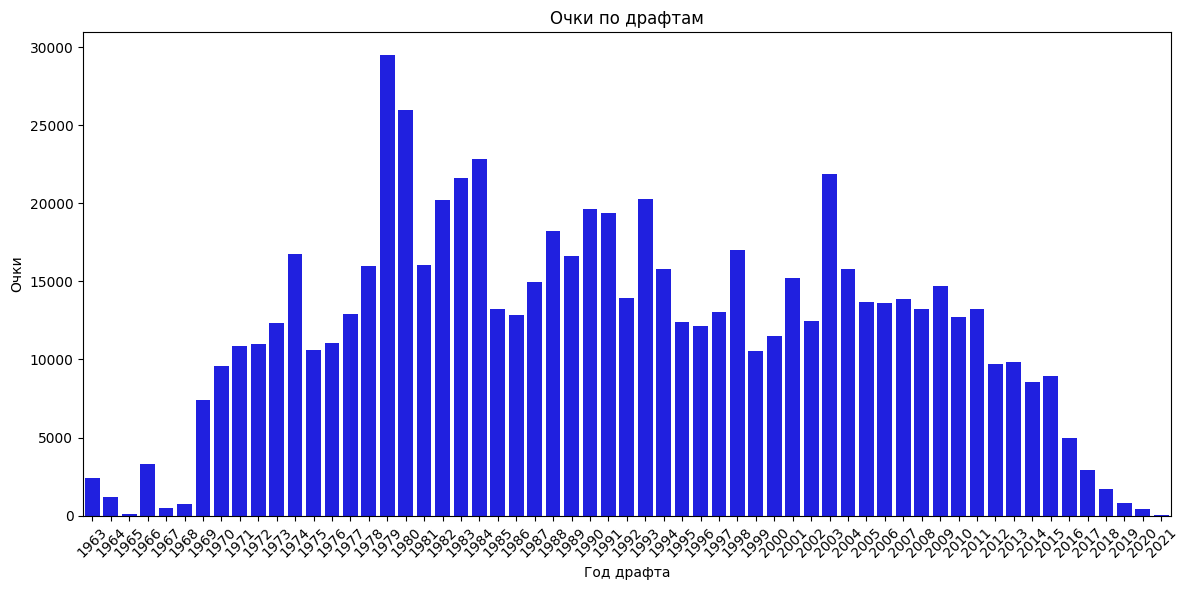

In [26]:
points = stats.groupby('year')['points'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=points, x='year', y='points', color='blue')

plt.title('Очки по драфтам')
plt.xlabel('Год драфта')
plt.ylabel('Очки')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

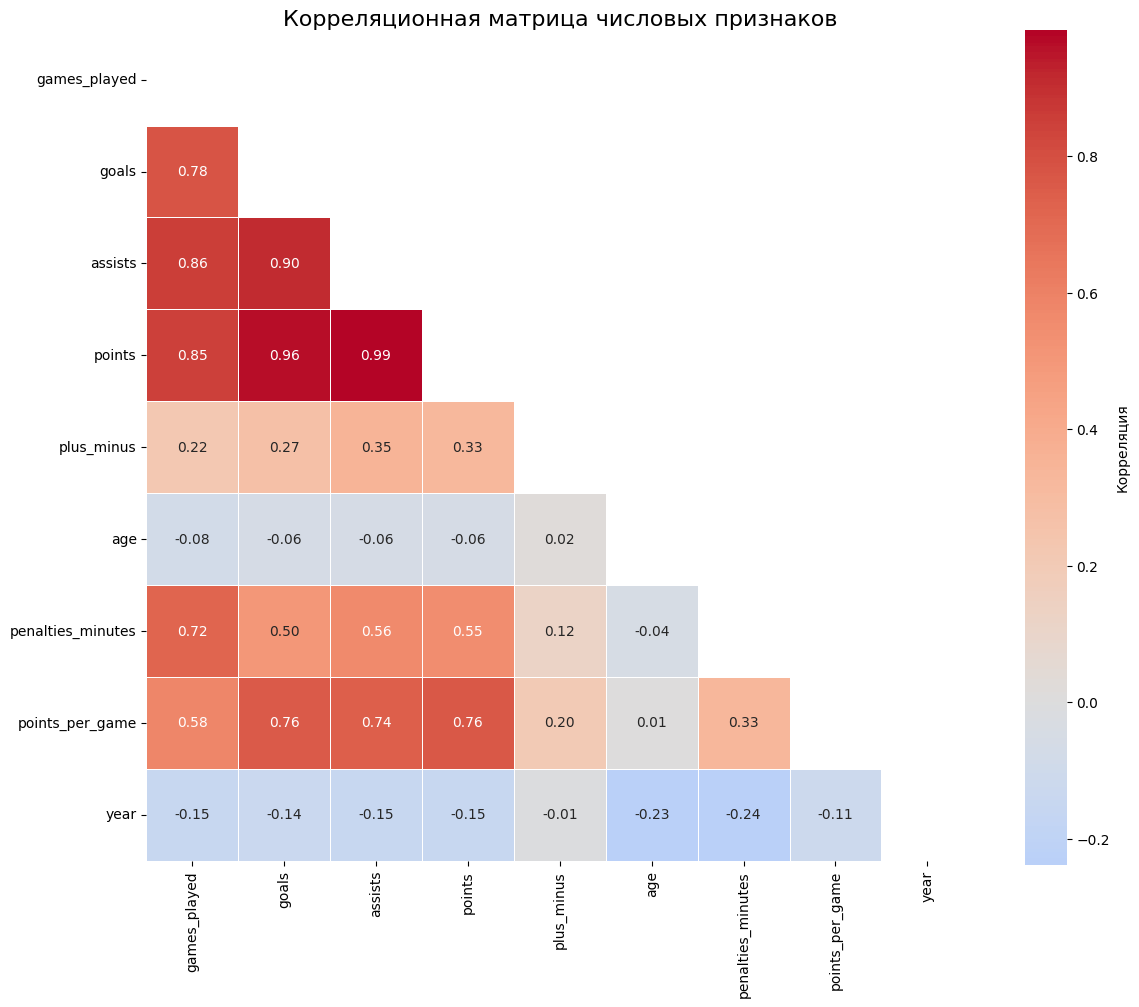

In [28]:
# Выбираем числовые колонки для корреляции
numeric_cols = [
    'games_played',  # сыгранные матчи
    'goals',         # голы
    'assists',       # передачи
    'points',        # очки
    'plus_minus',    # полезность
    'age',           # возраст на драфте
    'penalties_minutes',  # штрафные минуты
    'points_per_game',           # очков за игру (если создал)
    'year'           # год драфта
]

# Считаем корреляцию
corr_matrix = stats[numeric_cols].corr()


plt.figure(figsize=(12, 10))

# Маска для верхнего треугольника (чтобы не дублировать)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Тепловая карта
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True,           # показывать числа
            fmt='.2f',             # формат чисел
            cmap='coolwarm',       # цветовая схема (красный = положит., синий = отриц.)
            center=0,              # центр в 0
            square=True,           # квадратные ячейки
            linewidths=0.5,        # линии между ячейками
            cbar_kws={'label': 'Корреляция'})

plt.title('Корреляционная матрица числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

- менее 50 % процентов игроков сыграли хотя бы 1 матч в НХЛ
- самая распространенная позиция - центральные нападающие 
- канада ожидаемо как родина хоккея производит наибольшее число игроков
- пик результативности пришелся на 70-е и 80-е годы
- пик европейского нашествия начинается примерно в середине 80-х годов
- драфт 2003 года - на данный момент лучший в XXI веке
- драфт 1979 года - статистически лучший в XX веке


Гипотезы:
- раз в 10-15 лет появляется снайпер, который забьет в районе 800 шайб
- тренд на увелечение европейского влияния в НХЛ сохранится
- в ближайшие 20 лет не будет периода, в котором результативность вернется на уровень 70-x и 80-х 

Брал подсказки касательно параметров в функциях для графиков, как задать столбцы, провести какие-то линии, какой тип лучше использовать для какой ситуации in general

Мне нравится спорт, нравится копаться в статистических данных, поэтому вероятно продолжением станет еще больший датасет с большим числом уникальных данных о хоккее или в другом виде спорта